In [2]:
import numpy as np
import matplotlib.pyplot as plt

Si considera un sistema di $N$ particelle, soggetto al potenziale di Lennard-Jones e con condizioni periodiche al contorno, rappresentativo di un liquido a temperatura $T$ e densità $\rho$.

L'obiettivo è stimare, mediante simulazione numerica, le seguenti proprietà del sistema:

* **energia potenziale per particella**;
* **pressione**;
* **funzione di distribuzione radiale** $g(r)$.

A tal fine vengono considerate due diverse tecniche di simulazione:

* **Dinamica Molecolare (MD)**, utilizzando l'algoritmo di Verlet;
* **Monte Carlo (MC)**, utilizzando l'algoritmo di Metropolis nell'ensemble canonico (NVT).

Per una particella (i), viene proposta una traslazione casuale:

$$
\Delta x_j \sim U(-\delta,\delta),
$$

per ciascuna componente spaziale $j$. La particella viene quindi temporaneamente spostata e viene calcolata la variazione di energia

$$
\Delta E = E_{\mathrm{new}}-E_{\mathrm{old}},
$$


La probabilità di accettazione della mossa è

$$
P_{\mathrm{acc}}=\min\left(1,e^{-\beta\Delta E}\right).
$$



# Esercizio 7.2

## Monte Carlo

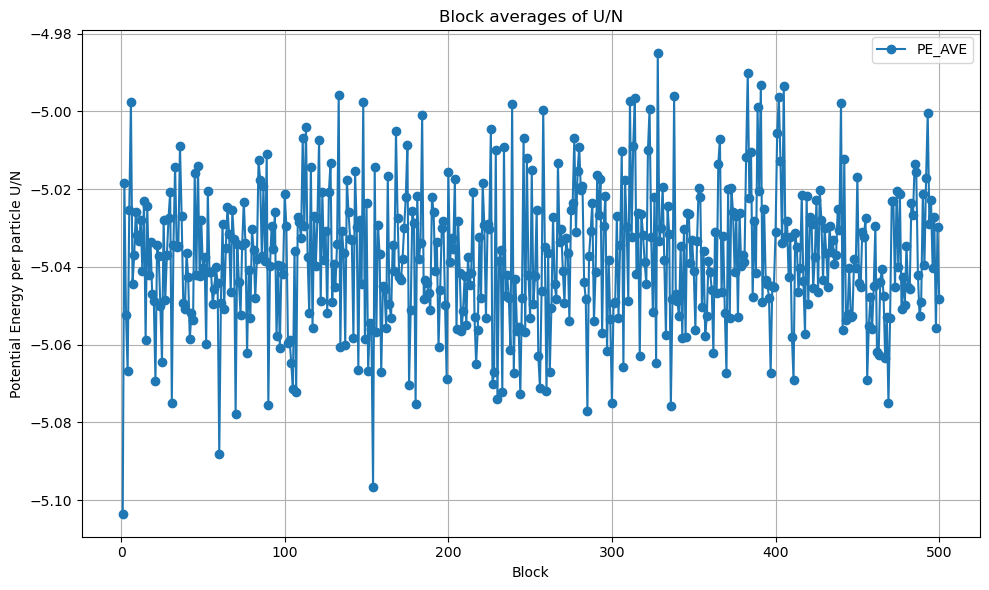

In [7]:
data = np.loadtxt("OUTPUT/potential_energy.dat")

blocks = data[:, 0]
actual_pe = data[:, 1]
pe_ave = data[:, 2]

plt.figure(figsize=(10,6))
plt.plot(blocks, actual_pe, 'o-', label="PE_AVE")

plt.xlabel("Block")
plt.ylabel("Potential Energy per particle U/N")
plt.title("Block averages of U/N")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Molecular Dynamics

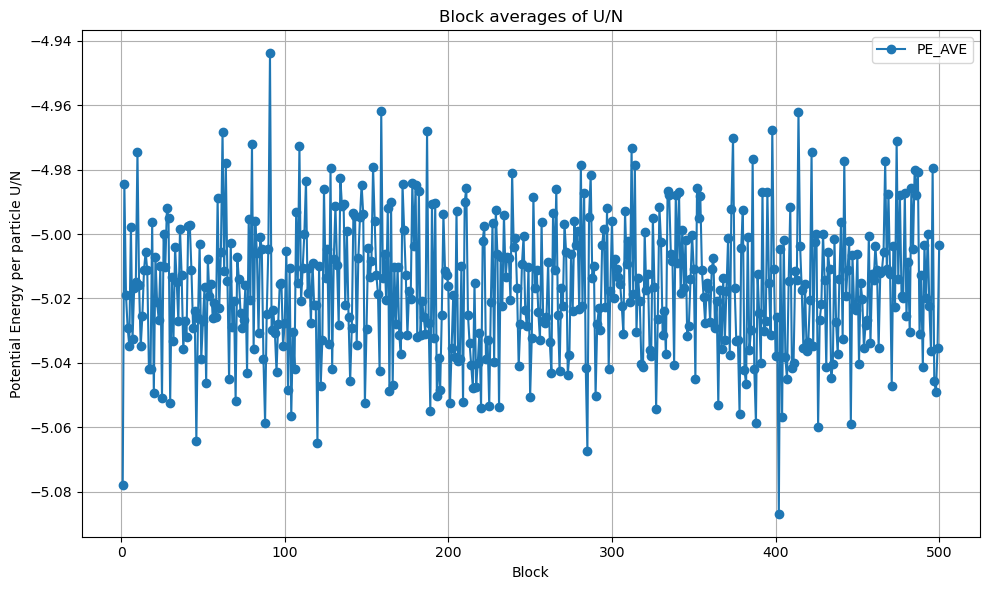

In [3]:
data = np.loadtxt("OUTPUT/potential_energy_MD.dat")

blocks = data[:, 0]
actual_pe = data[:, 1]
pe_ave = data[:, 2]

plt.figure(figsize=(10,6))
plt.plot(blocks, actual_pe, 'o-', label="PE_AVE")

plt.xlabel("Block")
plt.ylabel("Potential Energy per particle U/N")
plt.title("Block averages of U/N")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Autocorrelazione

L'autocorrelazione time displaced di una variabile \(X\) indica quanto la variabile sia correlata con se stessa traslata di un intervallo di tempo \(t\) e si calcola come:

$$
AC_X(t) =
\frac{
\langle X(t')X(t'+t)\rangle_{t'}
-
\langle X(t')\rangle_{t'}^2
}{
\sigma_X^2
}
$$

Se ora si considera una variabile $X$ misurata per $M$ step discreti di lunghezza uniforme, l'autocorrelazione al passo (o tempo) $m$ è per $M \gg m$:

$$
AC_X(m)=
\frac{
\frac{1}{M-m}\displaystyle\sum_{i=0}^{M-m}X(i)X(i+m)
-
\left(\frac{1}{M-m}\displaystyle\sum_{i=0}^{M-m}X(i)\right)
\left(\frac{1}{M-m}\displaystyle\sum_{i=0}^{M-m}X(i+m)\right)
}{
\frac{1}{M}\displaystyle\sum_{i=0}^{M}X(i)^2
-
\left(\frac{1}{M}\displaystyle\sum_{i=0}^{M}X(i)\right)^2
}
$$

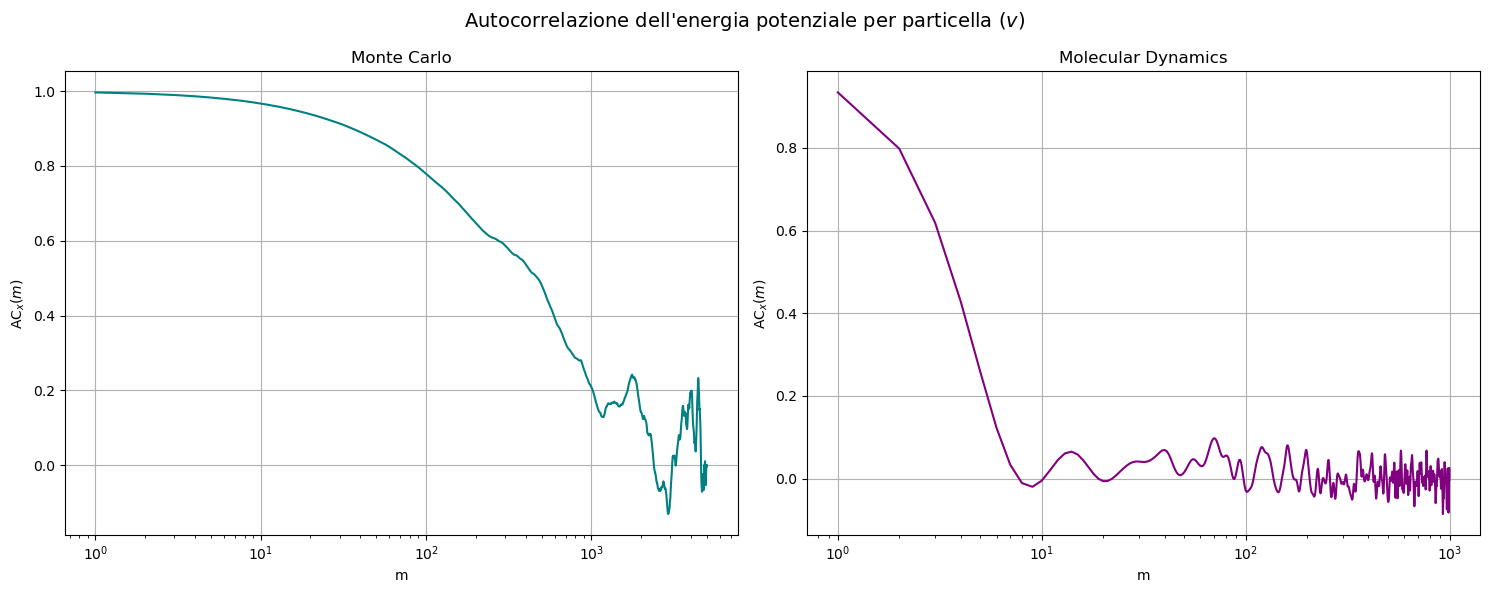

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def autocorr_num(x, m, M):
    x_start = x[:M-m]
    x_end   = x[m:]
    norm = 1/(M-m)

    sum1 = np.dot(x_start, x_end)
    sum2 = x_start.sum()
    sum3 = x_end.sum()

    return norm * (sum1 - norm * sum2 * sum3)

def calc_autocorr(x, m_val, M):
    den = x.var()
    corr = np.zeros_like(m_val, dtype=float)

    for i, m in enumerate(m_val):
        corr[i] = autocorr_num(x, int(m), M)

    return corr / den


# Monte Carlo
mc_raw = np.loadtxt("OUTPUT/potential_energy_MD.dat")
mc_u   = mc_raw[:, 1]     # ACTUAL_PE
M_mc   = len(mc_u)

# Molecular Dynamics
md_raw = np.loadtxt("OUTPUT/potential_energy.dat")
md_u   = md_raw[:, 1]     # ACTUAL_PE
M_md   = len(md_u)


m_val_mc = np.arange(1, min(5000, M_mc))
m_val_md = np.arange(1, min(1000, M_md))

AC_mc = calc_autocorr(mc_u, m_val_mc, M_mc)
AC_md = calc_autocorr(md_u, m_val_md, M_md)

fig, axs = plt.subplots(1, 2, figsize=(15, 6))

# Monte Carlo
axs[0].plot(m_val_mc, AC_mc, lw=1.5, color="teal")
axs[0].set_xlabel("m")
axs[0].set_ylabel(r"$\mathrm{AC}_{x}(m)$")
axs[0].set_title("Monte Carlo")
axs[0].grid(True)
axs[0].semilogx()

# Molecular Dynamics
axs[1].plot(m_val_md, AC_md, lw=1.5, color="purple")
axs[1].set_xlabel("m")
axs[1].set_ylabel(r"$\mathrm{AC}_{x}(m)$")
axs[1].set_title("Molecular Dynamics")
axs[1].grid(True)
axs[1].semilogx()

fig.suptitle(r"Autocorrelazione dell'energia potenziale per particella ($v$)", fontsize=14)
plt.tight_layout()
plt.show()


## Data Blocking

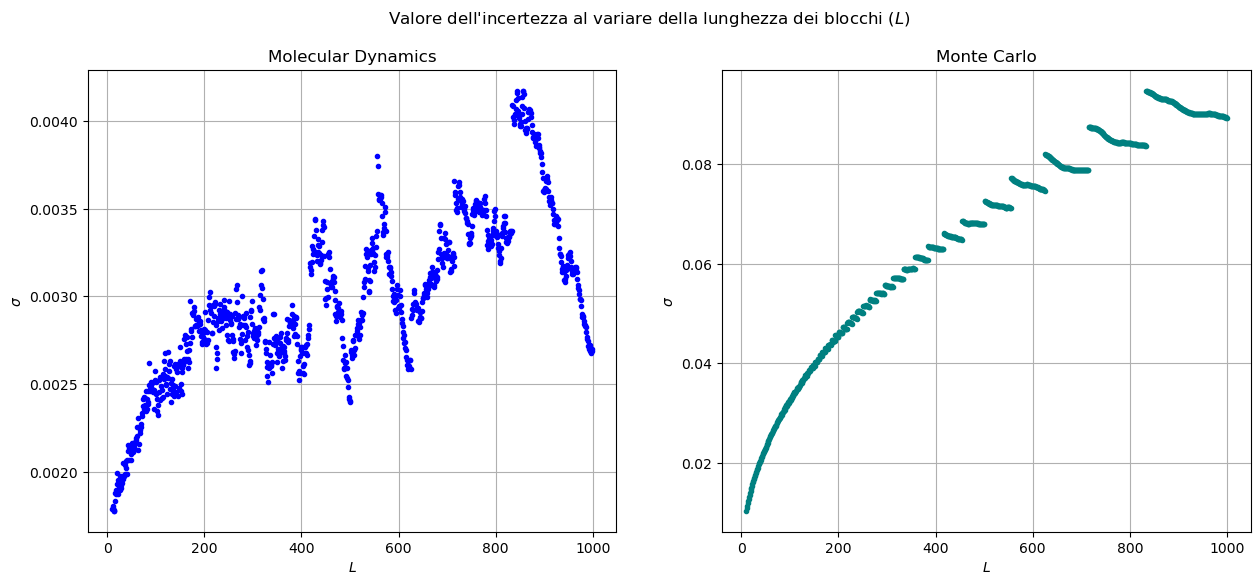

In [10]:
L_list=np.arange(10,1000,1)
M=5000
N_list = M // L_list
MD_error=np.zeros(len(L_list))
MC_error=np.zeros(len(L_list))

data = np.loadtxt("OUTPUT/potential_energy.dat", comments="#")
MD_pot_en_ = data[:, 1]

data1 = np.loadtxt("OUTPUT/potential_energy_MD.dat", comments="#")
MC_pot_en_ = data1[:, 1]


for i,(N,L) in enumerate(zip(N_list,L_list)):

    reshaped_data = MD_pot_en_[:N*L].reshape((N,L))#riorganizzati i dati in N righe e L colonne (se il divisore non è esatto, elimina qualche dato dalla coda)
    blk_mean=np.mean(reshaped_data,axis=1) #trova la media ogni riga (media del blocco)
    err=np.sqrt(((np.dot(blk_mean,blk_mean))/N- blk_mean.mean()**2)/N)
    MD_error[i]=err

    reshaped_data = MC_pot_en_[:N*L].reshape((N,L))#riorganizzati i dati in N righe e L colonne (se il divisore non è esatto, elimina qualche dato dalla coda)
    blk_mean=np.mean(reshaped_data,axis=1) #trova la media ogni riga (media del blocco)
    err=np.sqrt(((np.dot(blk_mean,blk_mean))/N- blk_mean.mean()**2)/N)
    MC_error[i]=err
    
fig,axs=plt.subplots(1,2,figsize=[15,6])


axs[0].plot(L_list,MD_error,".",color="blue")
axs[0].set_xlabel(r"$L$")
axs[0].set_ylabel(r"$\sigma$")
axs[0].grid()
#axs[0].semilogx()
axs[0].set_title("Molecular Dynamics")
axs[1].plot(L_list,MC_error,".",color="teal")
axs[1].set_xlabel(r"$L$")
axs[1].set_ylabel(r"$\sigma$")
axs[1].grid()
#axs[1].semilogx()
axs[1].set_title("Monte Carlo")
fig.suptitle(r"Valore dell'incertezza al variare della lunghezza dei blocchi ($L$) ");

### Commento
L'incertezza cresce all'aumentare della grandezza dei blocchi utilizzati per calcolarla. Da un certo valore in poi si assesta attorno ad un certo valore costante. Nel Monte Carlo non vedo questo comportamento a causa del basso numero di $L$. 

# Esercizio 7.4

## g(r)

Sia dato un sistema a $N$ particelle con una distribuzione di probabilità congiunta $\rho(\vec r_1,\ldots,\vec r_N)$.

Si definisce la densità a $n$ particelle:

$$
\rho_N^{(n)}(\vec r_1,\ldots,\vec r_n)
=
\frac{N!}{(N-n)!}
\int d\vec r_{n+1}\cdots d\vec r_N\,
\rho(\vec r_1,\ldots,\vec r_N)
$$

e la distribuzione a $n$ particelle:

$$
g_N^{(n)}(\vec r_1,\ldots,\vec r_n)
=
\frac{
\rho_N^{(n)}(\vec r_1,\ldots,\vec r_n)
}{
\displaystyle\prod_{i=1}^{n}\rho_N^{(1)}(\vec r_i)
}
$$

La funzione di distribuzione radiale $g(r)$ è la distribuzione a due particelle per un sistema omogeneo, per il quale $\rho_N^{(1)}(\vec r)$ è una costante:

$$
\rho_N^{(1)}(\vec r)=\rho=\frac{N}{V}
$$

Pertanto:

$$
g_N^{(2)}(\vec r_1,\vec r_2)
=
g_N^{(2)}(|\vec r_1-\vec r_2|)
=
g(r)
$$

### Calcolo numerico

Operativamente, calcolare $g(r)$ significa costruire un istogramma con bin di grandezza $dr$. Si indica con $r$ il bordo sinistro del bin.

Ciclando sulle coppie di particelle, si calcola la loro distanza $d$. Se:

$$
r \leq d < r+dr
$$

si individua il bin corrispondente e si aumenta il conteggio di $2$.

Al termine, si normalizza dividendo per:

$$
\rho N\Delta V
$$

dove:

$$
\Delta V
=
\frac{4}{3}\pi\left[(r+dr)^3-r^3\right]
$$

Quindi:

$$
g(r)
=
\frac{\text{conteggio nel bin}}
{\rho N\Delta V}
$$

Per la simulazione è stato scelto un numero di 100 bin.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# MONTE CARLO
data_MC = np.loadtxt("OUTPUT/gofr_MD.dat")
r_MC     = data_MC[:, 0]
g_MC     = data_MC[:, 1]

# MOLECULAR DYNAMICS 
data_MD = np.loadtxt("OUTPUT/gofr.dat")
r_MD     = data_MD[:, 0]
g_MD     = data_MD[:, 1]

plt.figure(figsize=(14,5))

# MONTE CARLO
plt.subplot(1,2,1)
plt.bar(r_MC, g_MC,
        width=0.02,
        color="steelblue",
        edgecolor="black",
        alpha=0.8)
plt.xlabel("r")
plt.ylabel("g(r)")
plt.title("Monte Carlo")
plt.grid(axis='y', alpha=0.4)

# MOLECULAR DYNAMICS
plt.subplot(1,2,2)
plt.bar(r_MD, g_MD,
        width=0.02,
        color="darkred",
        edgecolor="black",
        alpha=0.8)
plt.xlabel("r")
plt.ylabel("g(r)")
plt.title("Molecular Dynamics")
plt.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

## Pressione

La pressione può essere calcolata tramite il valore medio del viriale $W$:

$$
W=-r\frac{dU}{dr}
$$

e quindi:

$$
P=\rho k_B T+\frac{\langle W\rangle}{3V}
$$

Le correzioni di coda si ottengono con un calcolo analogo al precedente:

$$
\frac{\langle W_{\text{tail}}\rangle}{3N\epsilon}
\simeq
\frac{32\pi\rho}{3}
\left(
\frac{1}{3r_{\text{cut,LJ}}^9}
-
\frac{1}{2r_{\text{cut,LJ}}^3}
\right)
$$

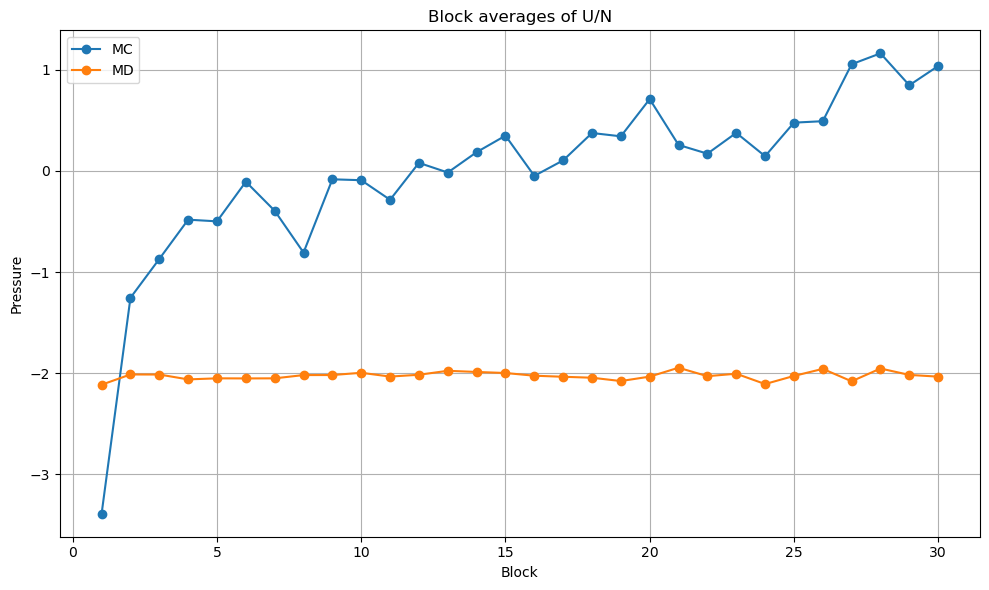

In [21]:
data = np.loadtxt("OUTPUT/pressure.dat") # montecarlo
data1 = np.loadtxt("OUTPUT/pressure_MD.dat") # MD

blocks = data[:, 0]
actual_pe = data[:, 1]
pe_ave = data[:, 2]

blocks1 = data1[:, 0]
actual_pe1 = data1[:, 1]
pe_ave1 = data1[:, 2]

plt.figure(figsize=(10,6))
plt.plot(blocks, actual_pe, 'o-', label="MC")
plt.plot(blocks1, actual_pe1, 'o-', label="MD")

plt.xlabel("Block")
plt.ylabel("Pressure")
plt.title("Block averages of U/N")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Energia Potenziale

Per un potenziale di Lennard-Jones, eseguendo analiticamente il calcolo, si ottiene:

$$
\frac{\langle V_{\text{tail}}\rangle}{N}
\simeq
\frac{8\pi\rho\epsilon}{3}
\left(
\frac{1}{3r_{\text{cut,LJ}}^9}
-
\frac{1}{r_{\text{cut,LJ}}^3}
\right)
$$

dove $r_{\text{cut,LJ}}$ e $\epsilon$ sono espressi in unità di $\sigma$ del potenziale di Lennard-Jones.

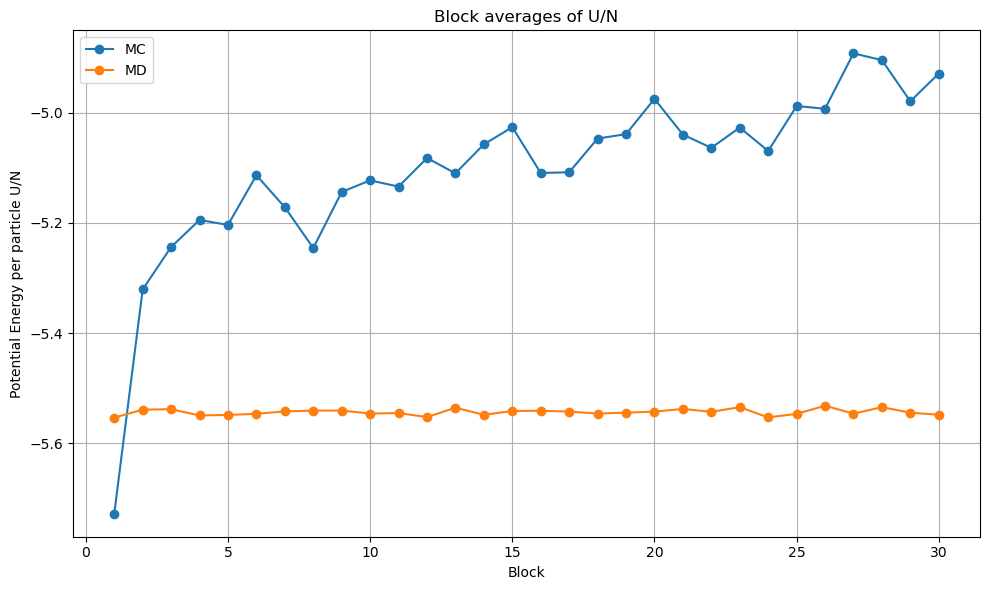

In [20]:
data = np.loadtxt("OUTPUT/potential_energy_MD.dat") # montecarlo
data1 = np.loadtxt("OUTPUT/potential_energy.dat")

blocks = data[:, 0]
actual_pe = data[:, 1]
pe_ave = data[:, 2]

blocks1 = data1[:, 0]
actual_pe1 = data1[:, 1]
pe_ave1 = data1[:, 2]

plt.figure(figsize=(10,6))
plt.plot(blocks, actual_pe, 'o-', label="MC")
plt.plot(blocks1, actual_pe1, 'o-', label="MD")

plt.xlabel("Block")
plt.ylabel("Potential Energy per particle U/N")
plt.title("Block averages of U/N")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Commento
Nel calcolo della pressione e dell'energia potenziale si nota come i valori nelle simulazioni Monte Carlo e Molecular Dynamics abbiano valori differenti.